# SleepSense — Analisi Correlazione

**Sections:**
1. Installazione librerie necessarie
2. Import delle librerie
3. Load CSV files
4. Cleaning & preprocessing
5. Exploratory plots
6. Correlation analysis (Pearson, Spearman, Kendall)
7. Lagged and rolling correlations
8. Frequency analysis (FFT)
9. Clustering (KMeans)
10. Logistic regression (predict movement)

Adjust the `DATA_GLOB_PATH` to your CSV folder path and run all cells.

In [21]:
# 1) Installazione librerie necessarie
'''
%pip install -U scikit-learn
%pip install plotly
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install matplotlib
%pip install jupyterlab
%pip install notebook
%pip install ipywidgets
%pip install plotly-express
%pip install plotly.graph_objects
%pip install statsmodels
'''

'\n%pip install -U scikit-learn\n%pip install plotly\n%pip install pandas\n%pip install numpy\n%pip install seaborn\n%pip install matplotlib\n%pip install jupyterlab\n%pip install notebook\n%pip install ipywidgets\n%pip install plotly-express\n%pip install plotly.graph_objects\n%pip install statsmodels\n'

In [22]:
# 2) Import delle librerie
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from scipy.stats import spearmanr, pearsonr
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
print('Libraries loaded')

Libraries loaded


In [23]:
# 3) Load CSV files
DATA_GLOB_PATH = r"C:/Users/leopi/Il mio Drive/Desktop/Magistrale/IoT_ESP_SleepSense/Misurazioni/*.csv" 
files = glob.glob(DATA_GLOB_PATH)
print(f'Trovati {len(files)} files')

dfs = []
for f in files:
    try:
        df = pd.read_csv(f)
        dfs.append(df)
    except Exception as e:
        print('Error reading', f, e)

df_all = pd.concat(dfs, ignore_index=True) if len(dfs)>0 else pd.DataFrame()
print('Dataframe shape:', df_all.shape)

# 4) Cleaning dei database
df_all['_time'] = pd.to_datetime(df_all.get('_time', pd.Series()), utc=True, errors='coerce', format="mixed")
cols_to_numeric = ['humidity','light','mic','temperature','is_moving',
                   'accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
df_all[cols_to_numeric] = df_all[cols_to_numeric].apply(pd.to_numeric, errors="coerce")

df_all = df_all.dropna(subset=cols_to_numeric)
df_all["_time"] = df_all["_time"].dt.tz_convert(None)
df_all["_time"] = df_all["_time"].dt.strftime("%Y-%m-%d %H:%M:%S")
df_all["_time"] = pd.to_datetime(df_all["_time"], format="%Y-%m-%d %H:%M:%S")
df_all = df_all.sort_values("_time")
df_all

Trovati 13 files
Dataframe shape: (4667, 16)


,_time,_measurement,host,location,room,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,humidity,light,mic,temperature,is_moving
0,2025-11-07 00:20:20,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133871,0.022258,1.032581,0.224516,0.271613,0.001290,59.800000,0.0,13.258065,21.000000,0
1,2025-11-07 00:21:17,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133882,0.022235,1.033529,0.282118,0.290706,0.007412,59.683529,0.0,13.070588,21.037647,0
2,2025-11-07 00:22:15,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133837,0.022326,1.032558,0.284651,0.336512,-0.006395,59.508140,0.0,13.930233,21.100000,0
3,2025-11-07 00:23:12,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133563,0.022529,1.033103,0.297471,0.291034,-0.036782,59.416092,0.0,11.413793,21.116092,0
4,2025-11-07 00:24:10,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.132442,0.022093,1.033605,0.310116,0.344651,0.004070,59.329070,0.0,12.790698,21.200000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4662,2025-12-13 05:23:40,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.000000,0.000000,1.000526,0.075263,-0.128421,-0.025789,67.400000,0.0,10.842105,19.400000,100
4663,2025-12-13 05:24:15,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.000000,0.000000,1.001111,0.037778,-0.062222,-0.006667,68.955556,0.0,0.000000,19.422222,100
4664,2025-12-13 05:26:35,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.000000,0.000000,1.001250,-0.380000,0.513750,0.133750,68.912500,0.0,3.750000,19.500000,0
4665,2025-12-13 05:27:10,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.000000,0.000000,1.000000,-1.205000,2.253333,0.718333,68.433333,0.0,7.833333,19.500000,0


In [24]:
# 5) Plot esplorativi
cols_plot = ['is_moving', 'humidity', 'light', 'mic', 'temperature', 'gyro_x','gyro_y','gyro_z', 'accel_x','accel_y','accel_z']
cols_plot = [c for c in cols_plot if c in df_all.columns]
df_plot = df_all.copy()
df_plot[cols_plot] = df_plot[cols_plot].fillna(0)
# Plot serie temporale
fig = px.line(df_plot, x='_time', y=cols_plot, title='Valori nel tempo')
fig.update_layout(xaxis_title='Time', yaxis_title='Value', legend_title='Misurazioni')
fig.show()
# Plot dei dati senza tempo
fig = px.line(df_plot, y=cols_plot, title="Plot delle variabili affiancate (senza tempo)")
fig.update_layout(xaxis_title="Index", yaxis_title="Sensor Values")
fig.show()

# Plot distribuzioni
df_long = df_all.melt(
    value_vars=cols_plot,
    var_name="Sensor",
    value_name="Value"
)
fig = px.violin(
    df_long,
    x="Sensor",
    y="Value",
    color="Sensor",
    box=True,
    points="outliers",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title="Distribuzione dei sensori (Violin plot)"
)
fig.update_traces(
    meanline_visible=True,
    opacity=0.85,
    width=0.8
)
fig.update_layout(
    violinmode="group",
    height=500,
    width=1200,
    title_x=0.5,
    showlegend=False,
    yaxis_title="Valore",
    xaxis_title=""
)
fig.show()

In [25]:
# 6) Analisi di correlazione (Pearson, Spearman, Kendall)
df_all["is_moving"] = (df_all["is_moving"] != 0).astype(int)
cols_corr = ['humidity','light','mic','temperature','is_moving']
cols_corr = [c for c in cols_corr if c in df_all.columns]
df_clean_corr = df_all[cols_corr].dropna()
pearson = df_clean_corr.corr(method='pearson')
spearman = df_clean_corr.corr(method='spearman')
kendall = df_clean_corr.corr(method='kendall')
'''
print('Pearson:\n', pearson.round(3))
print('\nSpearman:\n', spearman.round(3))
print('\nKendall:\n', kendall.round(3))
'''

z_pear = pearson.values
z_spear = spearman.values
z_kend = kendall.values
z_pear_text = np.round(z_pear, 2).astype(str).tolist()
z_spear_text = np.round(z_spear, 2).astype(str).tolist()
z_kend_text  = np.round(z_kend,  2).astype(str).tolist()
labels_x = pearson.columns.tolist()
labels_y = pearson.index.tolist()

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Pearson", "Spearman", "Kendall"),
    horizontal_spacing=0.1
)

# Heatmap 1 - Pearson
fig.add_trace(
    go.Heatmap(z=z_pear,x=labels_x,y=labels_y,colorscale="tempo",zmin=-1, zmax=1,showscale=True,text=z_pear_text,
        texttemplate="%{text}",
        textfont=dict(size=11, color="white")),
    row=1, col=1
)

# Heatmap 2 - Spearman
fig.add_trace(
    go.Heatmap(z=z_spear,x=labels_x,y=labels_y,colorscale="ylorrd",zmin=-1, zmax=1,showscale=True,text=z_spear_text,
        texttemplate="%{text}",
        textfont=dict(size=11, color="white")),
    row=1, col=2
)

# Heatmap 3 - Kendall
fig.add_trace(
    go.Heatmap(z=z_kend,x=labels_x,y=labels_y,colorscale="ylgnbu",zmin=-1, zmax=1,showscale=False,text=z_kend_text,
        texttemplate="%{text}",
        textfont=dict(size=11, color="white")),
    row=1, col=3
)

fig.update_layout(
    title="Confronto delle Matrici di Correlazione",
    height=400,
    width=1200
)
fig.show()

vars_to_show = [c for c in cols_corr if c!='is_moving']
df_compare = pd.DataFrame({
    'variable': vars_to_show,
    'pearson': pearson.loc[vars_to_show,'is_moving'].values,
    'spearman': spearman.loc[vars_to_show,'is_moving'].values,
    'kendall': kendall.loc[vars_to_show,'is_moving'].values
})
fig = go.Figure()
fig.add_trace(go.Bar(x=df_compare['variable'], y=df_compare['pearson'], name='Pearson'))
fig.add_trace(go.Bar(x=df_compare['variable'], y=df_compare['spearman'], name='Spearman'))
fig.add_trace(go.Bar(x=df_compare['variable'], y=df_compare['kendall'], name='Kendall'))
y_min = df_compare[['pearson','spearman','kendall']].min().min()
y_max = df_compare[['pearson','spearman','kendall']].max().max()
fig.update_layout(barmode='group', title='Comparazione metriche',  height=400, width=600)
fig.show()

<Figure size 40000x60000 with 0 Axes>

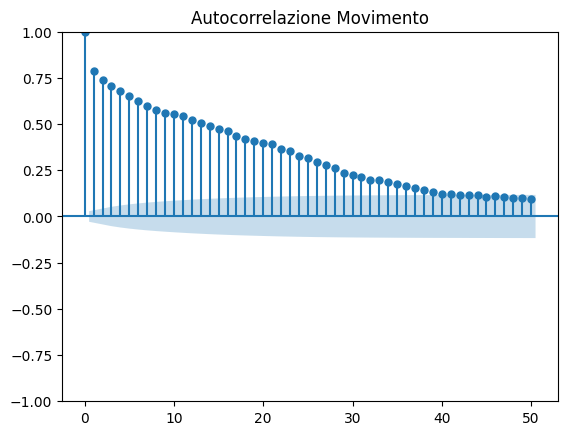

<Figure size 40000x60000 with 0 Axes>

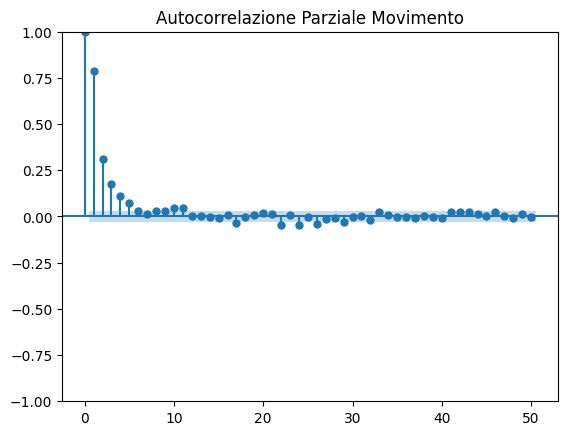

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(400, 600))
plot_acf(df_clean_corr["is_moving"], lags=50)
plt.title("Autocorrelazione Movimento")
plt.show()

plt.figure(figsize=(400, 600))
plot_pacf(df_clean_corr["is_moving"], lags=50)
plt.title("Autocorrelazione Parziale Movimento")
plt.show()

In [27]:
# 7) Lagged correlations
# Capire se un cambiamento nei dati ambientali precede o segue un movimento
lags_to_test = [0,1,5,10,20,50]  # lag values to test (in sample units)
lag_labels = [f'lag{i}' for i in lags_to_test]  # columns: lag1, lag2, ...
lag_results = {}

def lagged_correlation(series_x, series_y, lags):
    results = {}
    for lag in lags:
        try:
            val = series_x.shift(lag).corr(series_y)
        except Exception:
            val = None
        # round to 3 decimals when valid, else None
        if val is None or (isinstance(val, float) and np.isnan(val)):
            results[lag] = None
        else:
            results[lag] = round(val, 3)
    return results

# Lag correlation: 
# lag = 0 → correlazione normale
# lag > 0 → “il sensore cambia prima del movimento?”
# lag < 0 (qui non incluso) → “il sensore cambia dopo il movimento?”
if 'is_moving' in df_all.columns:
    sensors = [v for v in ['humidity','light','mic','temperature'] if v in df_all.columns]
    for v in sensors:
        res = lagged_correlation(df_all[v], df_all['is_moving'], lags_to_test)
        # keep values in the same order as lags_to_test; use None for missing
        values = [res.get(l) for l in lags_to_test]
        lag_results[v] = values
        # print summary per-sensor
        clean_res = {k: res[k] for k in res if res[k] is not None}
        if len(clean_res)>0:
            max_lag = max(clean_res, key=clean_res.get)
            min_lag = min(clean_res, key=clean_res.get)
            # print(f"\n=== {v.upper()} ===")
            # print("Lag → correlazione:", clean_res)
            # print(f"Lag max corr: {max_lag}  (corr={clean_res[max_lag]})")
            # print(f"Lag min corr: {min_lag}  (corr={clean_res[min_lag]})")

    # Build results DataFrame: sensors as rows, lag1..lagN as columns
    df_lags = pd.DataFrame.from_dict(lag_results, orient='index', columns=lag_labels)
    # df_lags.index.name = 'sensor'
    #display(df_lags)

    # Heatmap with annotated text overlay; highlight max per row in green and min in red
    try:
        z = df_lags.values.astype(float)
        fig = go.Figure(data=go.Heatmap(z=z, x=df_lags.columns, y=df_lags.index, colorscale='tempo', zmid=0, colorbar=dict(title='corr')))

        # Prepare per-cell text and color
        xs = []
        ys = []
        texts = []
        text_colors = []
        for i, row in enumerate(df_lags.index):
            row_vals = df_lags.loc[row].values.astype(float)
            mask = ~np.isnan(row_vals)
            if mask.any():
                max_idx = int(np.nanargmax(row_vals))
                min_idx = int(np.nanargmin(row_vals))
            else:
                max_idx = min_idx = None
            for j, val in enumerate(row_vals):
                xs.append(df_lags.columns[j])
                ys.append(row)
                if np.isnan(val):
                    texts.append("")
                    text_colors.append('black')
                else:
                    texts.append(f"{val:.3f}")
                    if (max_idx is not None) and (j == max_idx):
                        text_colors.append('lightgreen')
                    elif (min_idx is not None) and (j == min_idx):
                        text_colors.append('lightgrey')
                    else:
                        text_colors.append('white')

        scatter = go.Scatter(x=xs, y=ys, mode='text', text=texts, textfont=dict(color=text_colors, size=12), hoverinfo='none')
        fig.add_trace(scatter)
        fig.update_layout(title='Lagged correlations', height=400, width=600)
        fig.show()
    except Exception:
        pass


In [58]:
# Calcolo della finestra:

# Calcolo dei movimenti medi per sessione
gap = pd.Timedelta(hours=12)
df = df_all.copy()
df["session_id"] = (df["_time"].diff() > gap).cumsum()

df["movement_start"] = (
    (df["is_moving"] == 1) &
    (df["is_moving"].shift(1, fill_value=0) == 0)
).astype(int)

movements_per_session = (
    df.groupby("session_id")["movement_start"]
      .sum()
      .reset_index(name="n_movements")
)
# print(movements_per_session)
avg_num_moving = movements_per_session["n_movements"].mean()
print(f"Average number of movements per session: {avg_num_moving}")

# Calcolo della durata media del movimento (in tick)
df['group'] = (df['is_moving'] != df['is_moving'].shift()).cumsum()
movement_durations = df[df['is_moving'] == 1].groupby('group').size()
avg_movement_duration = movement_durations.mean()
print(f"Average movement duration (in ticks): {avg_movement_duration}")

# Differenza media tra una misurazione e l'altra
df_sorted = df_all.sort_values("_time").copy()

time_diffs = (
    df.groupby("session_id")["_time"]
    .diff()
    .dt.total_seconds()
    .dropna()
)
avg_time_diff = time_diffs.mean()
# print(time_diffs)
print(f"Average time difference between measurements (in seconds): {avg_time_diff}")

avg_time_moving = avg_movement_duration * avg_time_diff
print(f"Average time moving (in seconds): {avg_time_moving}")
print("minuti: ",avg_time_moving / 60)
print("ore: ",avg_time_moving / 3600)
print("Tempo medio per sessione: ", (avg_time_moving * avg_num_moving), "sec")
print("minuti:", (avg_time_moving * avg_num_moving) / 60)

print("Grandezza finestra consigliata (in tick):", (int(avg_time_diff * avg_movement_duration) ))

Average number of movements per session: 11.461538461538462
Average movement duration (in ticks): 5.704697986577181
Average time difference between measurements (in seconds): 60.66609368285346
Average time moving (in seconds): 346.0817424860768
minuti:  5.768029041434613
ore:  0.09613381735724355
Tempo medio per sessione:  3966.6292023404185 sec
minuti: 66.11048670567364
Grandezza finestra consigliata (in tick): 346


In [59]:
# 9) Rolling correlation
# Calcola la correlazione tra due serie temporali in una finestra mobile
from plotly.subplots import make_subplots
import plotly.graph_objects as go

window = 360
vars_plot = ['humidity','light','mic','temperature']
vars_plot = [v for v in vars_plot if v in df_all.columns]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"{v} vs is_moving" for v in vars_plot],
    shared_yaxes=True
)

positions = [(1,1), (1,2), (2,1), (2,2)]

for v, (r,c) in zip(vars_plot, positions):
    df_all[f'rollcorr_{v}'] = (
        df_all[v]
        .rolling(window=window, min_periods=10)
        .corr(df_all['is_moving'])
    )
    fig.add_trace(
        go.Scatter(
            y=df_all[f'rollcorr_{v}'],
            mode='lines',
            name=v
        ),
        row=r, col=c
    )

fig.update_layout(
    title=f"Rolling correlation (window={window}) vs is_moving",
    height=400,
    width=600,
    showlegend=False
)

fig.update_yaxes(range=[-1, 1])

fig.show()
